In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math

# Affiche toutes les lignes
pd.set_option('display.max_rows', None)

# Affiche toutes les colonnes
pd.set_option('display.max_columns', None)
# Choisis le nombre de caractère par colonnes
pd.set_option('display.max_colwidth', 50)

In [18]:
data_path = 'washington_ultimate.csv'

data_raw = pd.read_csv(data_path)

In [19]:
df = data_raw.copy()

In [20]:
loc_data = pd.read_csv('uszips.csv')

# On garde le code zip et la taille de la population des villes
loc_data = loc_data[['zip', 'population']]

In [21]:
# Fusion des deux jeu de données
df = pd.merge(df, loc_data, on='zip', how='left')

In [22]:
def cat_zip(row):
    zip_code = str(row['zip'])
    #
    #  Mégalopole urbaine et technologique
    if zip_code.startswith(('980', '981', '982')):
        return 'puget_sound_core'
    # Zones portuaires, capitale d'état, et côte Pacifique
    elif zip_code.startswith(('983', '985', '986')):
        return 'south_and_coast'
    # Vallées agricoles et viticoles
    elif zip_code.startswith(('988', '989')):
        return 'central_valleys'
    # Seconde métropole de l'état
    elif zip_code.startswith(('990', '992', '993')):
        return 'spokane_inland_empire'
    # Autres zones peu peuplées
    elif zip_code.startswith(('98', '99')) :
        return 'other'
    
df['group_zip'] = df.apply(cat_zip, axis=1)

### 1. zip / group_zip / population

Il n'y a que 3 à 5 NaN.   
Pas de similitude.   
On peut faire le choix de les supprimer ou de les remplacer par le mode.

In [23]:
df[['zip', 'group_zip', 'population']].isna().sum()

zip           3
group_zip     3
population    5
dtype: int64

In [24]:
df.loc[df['zip'].isna()]

,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text,population,group_zip
1011,NaN,land,NaN,425236.0,412067.0,0.9690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,retail lots at the fast growing intersection o...,NaN,NaN
2461,NaN,single_family,2015.0,1350060.0,1349920.0,0.9999,3250.0,415.36,2.0,6.0,4.0,3.0,4.0,2.0,this home is located in the heart of Kenmore. ...,NaN,NaN
10021,NaN,land,NaN,95096.0,94907.0,0.9980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,this is your rare opportunity to purchase a la...,NaN,NaN


In [25]:
# Everett, Washington (98206) --> 114,070 population en 2026
df.loc[(df['population'].isna()) & (~df['zip'].isna())]

,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text,population,group_zip
2913,98206.0,single_family,1966.0,455061.0,427576.0,0.9396,830.0,515.15,1.0,2.0,1.0,1.0,1.0,NaN,"private marina, sandy beaches, USGA golf cours...",NaN,puget_sound_core
11594,98206.0,single_family,1967.0,440092.0,440073.0,1.0000,900.0,488.97,1.0,1.0,1.0,NaN,1.0,NaN,private island bluff cabin w/ views of Puget S...,NaN,puget_sound_core


### 2. "year_built"
98% des terrains n'ont pas de date de construction. Les terrains avec une date sont des emplacements de port.   
Pas de similitude entre les NaN (remplacer par la médiane) :
- 293 code zip uniques
- Présent dans toutes les régions
- Tout type de propriété

In [26]:
print(f'Nombre de zip unique (year_built = NaN) : {df["zip"].loc[df["year_built"].isna()].nunique()}')

Nombre de zip unique (year_built = NaN) : 293


In [27]:
print('Pourcentage de propriété sans année de construction en fonction de la localisation :')
print()
print(df["group_zip"].loc[df['year_built'].isna()].value_counts().head(10) / df['year_built'].isna().sum() * 100)
print('\n10 plus grandes valeurs :')
print(df['zip'].loc[df['year_built'].isna()].value_counts().head(10) / df['year_built'].isna().sum() * 100)

Pourcentage de propriété sans année de construction en fonction de la localisation :

group_zip
south_and_coast          34.069767
puget_sound_core         33.837209
spokane_inland_empire    13.139535
central_valleys          12.441860
other                     6.279070
Name: count, dtype: float64

10 plus grandes valeurs :
zip
98229.0    6.279070
98382.0    1.627907
98816.0    1.627907
99006.0    1.627907
98640.0    1.627907
98042.0    1.627907
98569.0    1.511628
98584.0    1.395349
98230.0    1.279070
99352.0    1.279070
Name: count, dtype: float64


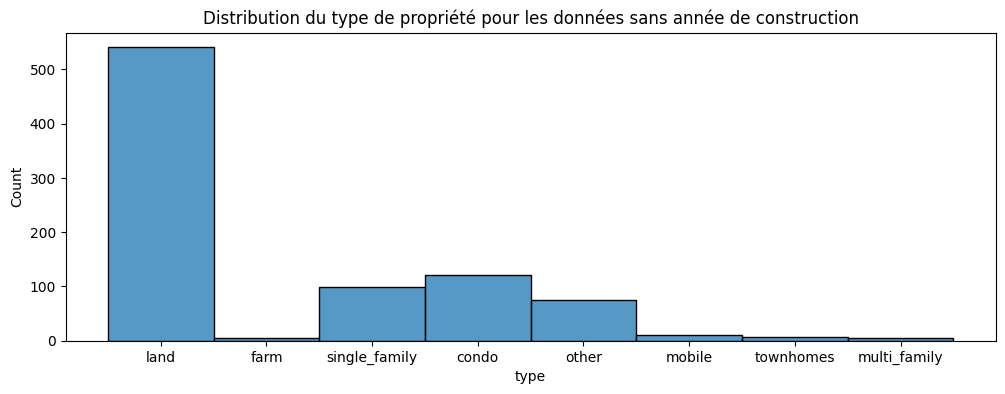

In [28]:
# Année de construction par rapport au type de propriété
plt.figure(figsize=(12,4))
sns.histplot(data=df.loc[df['year_built'].isna()], x='type')
plt.title('Distribution du type de propriété pour les données sans année de construction')
plt.show()

In [29]:
df.loc[(~df['year_built'].isna()) & (df['type'] == 'land')]

,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text,population,group_zip
313,98118.0,land,1965.0,79564.0,75100.0,0.9439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,parkshore marina on lake washington's east-fac...,50500.0,puget_sound_core
1454,98006.0,land,1978.0,175079.0,165068.0,0.9428,1570.0,105.14,NaN,NaN,NaN,NaN,NaN,NaN,"space is 80' X 19'6"" a 60-65' boat due to bein...",40009.0,puget_sound_core
2799,98110.0,land,2015.0,325070.0,317073.0,0.9754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"enjoy secure ownership, long-term moorage opti...",24631.0,puget_sound_core
3771,98110.0,land,2015.0,302316.0,302152.0,0.9995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"one of the [SIGNATURE REDACTED] slips, D-34 is...",24631.0,puget_sound_core
4977,98230.0,land,1982.0,48955.0,48838.0,0.9976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,the 36 foot fingerslip is close in and very se...,18744.0,puget_sound_core
5636,98332.0,land,1985.0,149938.0,145064.0,0.9675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a 32' boat slip at Murphy's Landing Marina in ...,20072.0,south_and_coast
6706,98370.0,land,1985.0,29949.0,29945.0,0.9999,360.0,83.18,NaN,NaN,NaN,NaN,NaN,NaN,"boat slip B-2 is at the base of ""B"" Dock. the ...",33655.0,south_and_coast
8659,98230.0,land,1982.0,179904.0,174932.0,0.9724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"50' slip offers easy ""blow on"" docking along t...",18744.0,puget_sound_core


### 3. "listPrice"
Pas de similitude.    
Utilisation médiane.

In [30]:
df.loc[df['listPrice'].isna()].head(20)

,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text,population,group_zip
1646,98685.0,single_family,2004.0,NaN,720054.0,NaN,2480.0,290.34,2.0,4.0,3.0,3.0,3.0,4.0,NaN,30607.0,south_and_coast
1894,98258.0,single_family,2016.0,NaN,722561.0,NaN,3190.0,226.51,2.0,5.0,5.0,4.0,4.0,NaN,NaN,52752.0,puget_sound_core
1910,98664.0,single_family,1970.0,NaN,409935.0,NaN,1040.0,394.17,1.0,3.0,2.0,2.0,2.0,NaN,NaN,23845.0,south_and_coast
1918,98290.0,single_family,1993.0,NaN,472103.0,NaN,1620.0,291.42,1.0,NaN,2.0,2.0,2.0,NaN,NaN,39826.0,puget_sound_core
1919,98682.0,single_family,1991.0,NaN,319910.0,NaN,1240.0,257.99,1.0,3.0,2.0,2.0,2.0,NaN,NaN,68305.0,south_and_coast
1939,98292.0,single_family,1993.0,NaN,849950.0,NaN,2170.0,391.68,1.0,3.0,2.0,2.0,2.0,NaN,NaN,27389.0,puget_sound_core
1951,98629.0,single_family,2005.0,NaN,829090.0,NaN,2770.0,299.31,1.0,4.0,3.0,2.0,2.0,NaN,NaN,9076.0,south_and_coast
2172,98208.0,single_family,1978.0,NaN,740068.0,NaN,2090.0,354.10,2.0,4.0,3.0,2.0,2.0,NaN,NaN,60915.0,puget_sound_core
2345,98801.0,single_family,1987.0,NaN,584937.0,NaN,2030.0,288.15,2.0,3.0,2.0,2.0,2.0,NaN,NaN,45426.0,central_valleys
2368,99352.0,single_family,1952.0,NaN,349923.0,NaN,1480.0,236.43,1.0,3.0,1.0,1.0,1.0,NaN,NaN,37430.0,spokane_inland_empire


In [31]:
df['type'].loc[df['listPrice'].isna()].value_counts()

type
single_family    1111
condo             244
other             111
mobile             86
land               55
townhomes          51
multi_family       34
Name: count, dtype: int64

### 4. "stories"
Pour "lands", stories = 0      
Pour "coop", pas de valeur pour stories ce qui pourrait être :
- Pas d'étage donc abscence à l'incrémentation donc = 0
- Erreur d'incrémentation (sur 5 valeurs ce qui est possible) donc on prendrais la médiane d'un type proche --> "condo" (tous les deux des copropriétés)

Pour les autres, utilisation de leurs médianes  

Type de propriété quand stories = NaN :
type
land             549
single_family    493
condo            152
multi_family     135
other             83
mobile            82
townhomes          8
coop               5
farm               4
Name: count, dtype: int64



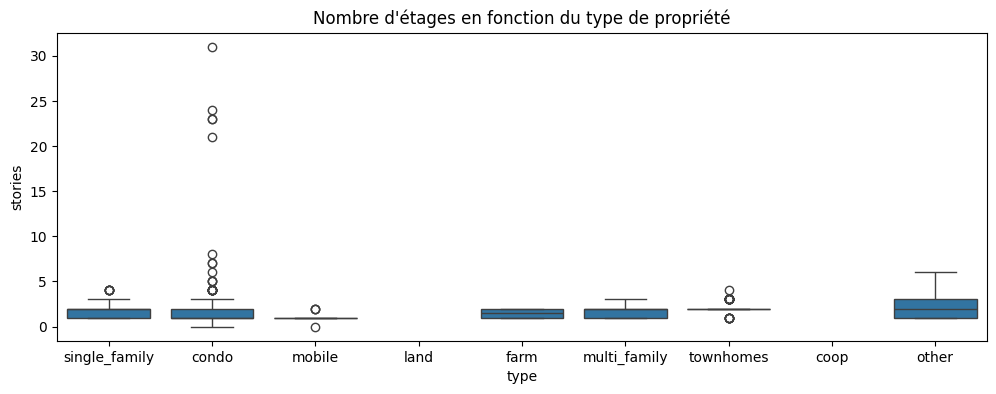

In [32]:
# Type de propriété quand stories = NaN
print('Type de propriété quand stories = NaN :')
print(f'{df.loc[df["stories"].isna(), "type"].value_counts()}\n')

# Nombre d'étages par rapport au type de propriété
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='type', y='stories')
plt.title("Nombre d'étages en fonction du type de propriété")
plt.show()

### 5. "beds"

Pour "lands", stories = 0   
Pour les autres, utilisation de leurs médianes 

Type de propriété quand stories = NaN :
type
land             549
single_family    140
other            103
condo             77
mobile            32
multi_family      23
farm               4
townhomes          4
Name: count, dtype: int64



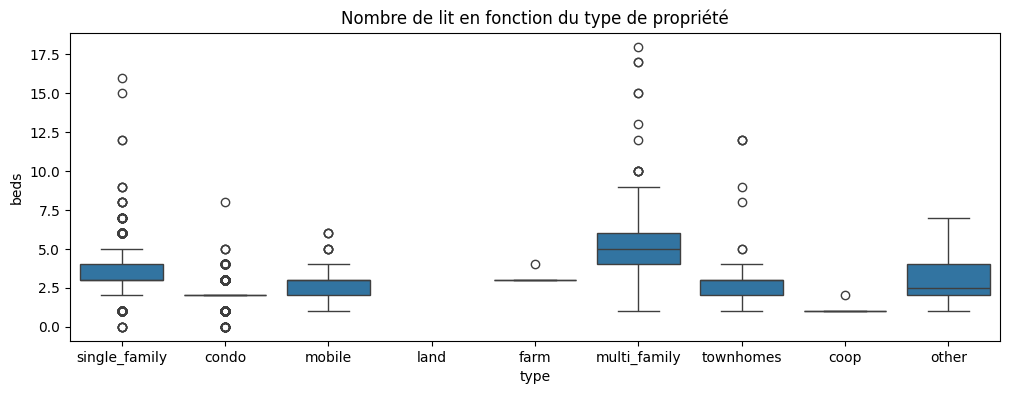

In [33]:
# Type de propriété quand beds = NaN
print('Type de propriété quand stories = NaN :')
print(f'{df.loc[df["beds"].isna(), "type"].value_counts()}\n')

# Nombre de lit par rapport au type de propriété
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='type', y='beds')
plt.title("Nombre de lit en fonction du type de propriété")
plt.show()

### 6. "garage"
Même reflexion qu'avec "stories"

Type de propriété quand stories = NaN :
type
single_family    6830
condo             966
mobile            556
land              549
townhomes         508
multi_family      125
other             105
farm               10
coop                5
Name: count, dtype: int64



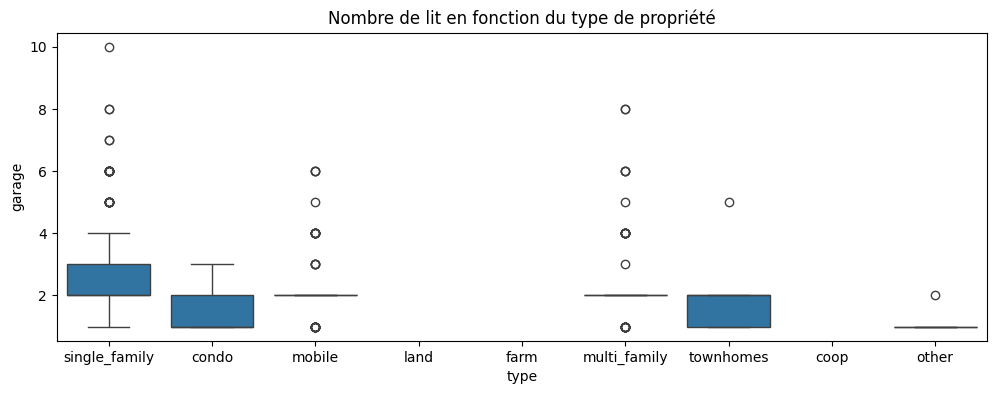

In [34]:
# Type de propriété quand beds = NaN
print('Type de propriété quand stories = NaN :')
print(f'{df.loc[df["garage"].isna(), "type"].value_counts()}\n')

# Nombre de lit par rapport au type de propriété
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='type', y='garage')
plt.title("Nombre de lit en fonction du type de propriété")
plt.show()

### 7. baths / baths_full / baths_full_calc
La majorité des NaN viennent de terrain ("land").    
C'est terrain n'ont pas de salle de bain --> "baths" = 0


type
land             467
multi_family       6
farm               4
condo              4
single_family      2
mobile             1
Name: count, dtype: int64


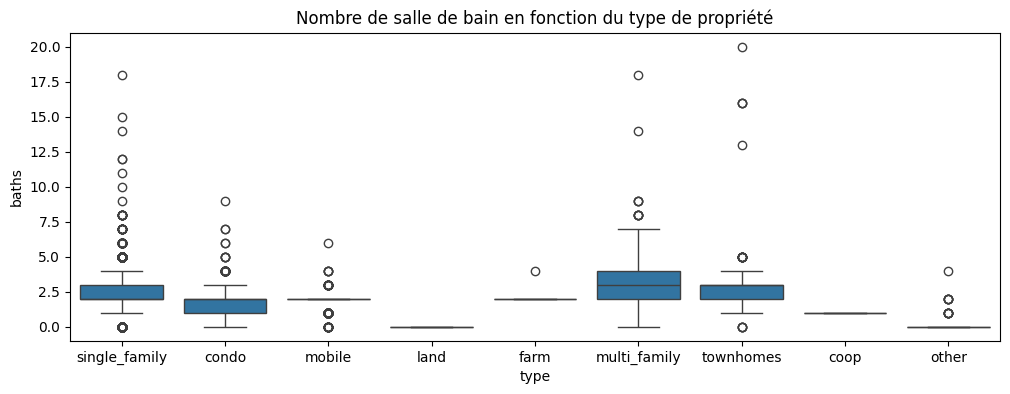

In [35]:
# Type de propriété quand bath = NaN
print(f'\n{df.loc[df["baths"].isna(), "type"].value_counts()}')

# Nombre de salle de bain par rapport au type de propriété
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='type', y='baths')
plt.title('Nombre de salle de bain en fonction du type de propriété')
plt.show()

In [36]:
print(df.loc[(df['type'] == "land"), 'baths'].value_counts())

baths
0.0    82
Name: count, dtype: int64


Quand "bath_full" ou "bath_full_calc" = NaN, "baths" est toujours un entier.   
- Que des half bath, ... ?    
- Erreur dans l'incrémentation des valeurs ?

In [37]:
# Nombre de salle de bain quand bath_full = NaN
print(f'\n{df.loc[df["baths_full"].isna(), "baths"].value_counts()}')


baths
0.0     419
1.0     123
2.0     122
3.0      46
4.0      38
6.0       5
5.0       5
8.0       4
9.0       2
18.0      1
7.0       1
Name: count, dtype: int64


In [38]:
# Nombre de salle de bain quand bath_full_calc = NaN
print(f'\n{df.loc[df["baths_full_calc"].isna(), "baths"].value_counts()}')


baths
0.0     419
2.0      40
4.0      33
1.0      11
3.0      10
6.0       5
8.0       4
5.0       4
9.0       2
18.0      1
7.0       1
Name: count, dtype: int64
